# Librerias

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Leer el dataset

In [3]:
train = pd.read_csv("./Data/raw/train.csv", parse_dates=["date"])
stores = pd.read_csv("./Data/raw/stores.csv")
transactions = pd.read_csv("./Data/raw/transactions.csv", parse_dates=["date"])
oil = pd.read_csv("./Data/raw/oil.csv", parse_dates=["date"])
holidays = pd.read_csv("./Data/raw/holidays_events.csv", parse_dates=["date"])

# Hipotesis

1. Promociones aumentan las ventas: Los productos en promoción tienen vengas mayores que los que no lo estan.
2. Influencia de los precios del petroleo: Una caída sostenida en el precio del crudo reduce el gasto público y el poder adquisitivo, lo que impacta las ventas de productos.
3. Estacionalidad: Las ventas cambian segun los dias de la semana (fines de semana mas altos), también depende de cuando hay vacaciones.
4. Tendencia temporal: Las ventas muestran una tendencia creciente o decreciente a lo largo del tiempo
5. Terromoto: El terremoto produjo un cambio significativo en las ventas, especialmente en determinadas categorías de productos, comparando el antes y el despues del evento.

UNION DE LOS DATASETS

In [4]:
#union de train con stores
train = train.merge(stores, on="store_nbr", how="left")

In [5]:
#juntamos el csv de transactions
train = train.merge(transactions, on=["date", "store_nbr"], how="left")

In [6]:
#unimos el oil
train = train.merge(oil, on="date", how="left")

In [7]:
#unimos el ultimo csv que es el de holidays
train = train.merge(holidays, on="date", how="left")

In [8]:
train.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type_x,cluster,transactions,dcoilwtico,type_y,locale,locale_name,description,transferred
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False


In [9]:
#ordena las fechas
train = train.sort_values("date")

In [10]:
#Divide el dataset en entrenamiento (hasta el 2017-01-01) y test (lo que queda) manteniendo el orden temporal, sin mezclar los datos.
"""idx = int(0.8*train.shape[0])
df_train = train.iloc[:idx, :]
df_test = train.iloc[idx:, :]
"""
fecha_corte= '2017-01-01'

df_train = train[train['date']<fecha_corte]
df_test =  train[train['date']>=fecha_corte]


print(train.shape[0], df_train.shape[0], df_test.shape[0], train.shape[0] == df_train.shape[0] + df_test.shape[0])

3054348 2642706 411642 True


In [11]:
df_train.to_csv('./Data/raw/df_train.csv', index=False)
df_test.to_csv('./Data/raw/df_test.csv', index=False)

In [12]:
df_train.shape

(2642706, 17)

In [13]:
df_train.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type_x,cluster,transactions,dcoilwtico,type_y,locale,locale_name,description,transferred
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
1194,1194,2013-01-01,42,CELEBRATION,0.0,0,Cuenca,Azuay,D,2,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
1193,1193,2013-01-01,42,BREAD/BAKERY,0.0,0,Cuenca,Azuay,D,2,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
1192,1192,2013-01-01,42,BOOKS,0.0,0,Cuenca,Azuay,D,2,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
1191,1191,2013-01-01,42,BEVERAGES,0.0,0,Cuenca,Azuay,D,2,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False


In [14]:
df_train.tail()

,id,date,store_nbr,family,sales,onpromotion,city,state,type_x,cluster,transactions,dcoilwtico,type_y,locale,locale_name,description,transferred
2641516,2595184,2016-12-31,25,SCHOOL AND OFFICE SUPPLIES,0.000,0,Salinas,Santa Elena,D,1,3401.0,NaN,Additional,National,Ecuador,Primer dia del ano-1,False
2641517,2595185,2016-12-31,25,SEAFOOD,29.634,1,Salinas,Santa Elena,D,1,3401.0,NaN,Additional,National,Ecuador,Primer dia del ano-1,False
2641518,2595186,2016-12-31,26,AUTOMOTIVE,13.000,0,Guayaquil,Guayas,D,10,1478.0,NaN,Additional,National,Ecuador,Primer dia del ano-1,False
2641519,2595187,2016-12-31,26,BABY CARE,0.000,0,Guayaquil,Guayas,D,10,1478.0,NaN,Additional,National,Ecuador,Primer dia del ano-1,False
2641515,2595183,2016-12-31,25,PRODUCE,5886.811,7,Salinas,Santa Elena,D,1,3401.0,NaN,Additional,National,Ecuador,Primer dia del ano-1,False


In [15]:
df_test.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type_x,cluster,transactions,dcoilwtico,type_y,locale,locale_name,description,transferred
2643889,2597557,2017-01-01,41,POULTRY,0.0,0,Machala,El Oro,D,4,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,True
2643897,2597565,2017-01-01,42,BEVERAGES,0.0,0,Cuenca,Azuay,D,2,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,True
2643896,2597564,2017-01-01,42,BEAUTY,0.0,0,Cuenca,Azuay,D,2,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,True
2643895,2597563,2017-01-01,42,BABY CARE,0.0,0,Cuenca,Azuay,D,2,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,True
2643894,2597562,2017-01-01,42,AUTOMOTIVE,0.0,0,Cuenca,Azuay,D,2,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,True


In [16]:
df_train.info()

<class 'pandas.DataFrame'>
Index: 2642706 entries, 0 to 2641515
Data columns (total 17 columns):
 #   Column        Dtype         
---  ------        -----         
 0   id            int64         
 1   date          datetime64[us]
 2   store_nbr     int64         
 3   family        str           
 4   sales         float64       
 5   onpromotion   int64         
 6   city          str           
 7   state         str           
 8   type_x        str           
 9   cluster       int64         
 10  transactions  float64       
 11  dcoilwtico    float64       
 12  type_y        str           
 13  locale        str           
 14  locale_name   str           
 15  description   str           
 16  transferred   object        
dtypes: datetime64[us](1), float64(3), int64(4), object(1), str(8)
memory usage: 362.9+ MB


In [17]:
# Almacenar columnas numéricas para evitar error
num_columns = df_train.select_dtypes(include=['number']).columns
num_columns

Index(['id', 'store_nbr', 'sales', 'onpromotion', 'cluster', 'transactions',
       'dcoilwtico'],
      dtype='str')

In [18]:
#almacenar las columnas categoricas
cat_columns = df_train.select_dtypes(include=['object']).columns
cat_columns

C:\Users\Laura\AppData\Local\Temp\ipykernel_17708\813583555.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_columns = df_train.select_dtypes(include=['object']).columns


Index(['family', 'city', 'state', 'type_x', 'type_y', 'locale', 'locale_name',
       'description', 'transferred'],
      dtype='str')

In [19]:
df_train.isnull().sum()

id                    0
date                  0
store_nbr             0
family                0
sales                 0
onpromotion           0
city                  0
state                 0
type_x                0
cluster               0
transactions     243771
dcoilwtico       819720
type_y          2193642
locale          2193642
locale_name     2193642
description     2193642
transferred     2193642
dtype: int64

In [20]:
df_train[cat_columns].isnull().sum()

family               0
city                 0
state                0
type_x               0
type_y         2193642
locale         2193642
locale_name    2193642
description    2193642
transferred    2193642
dtype: int64

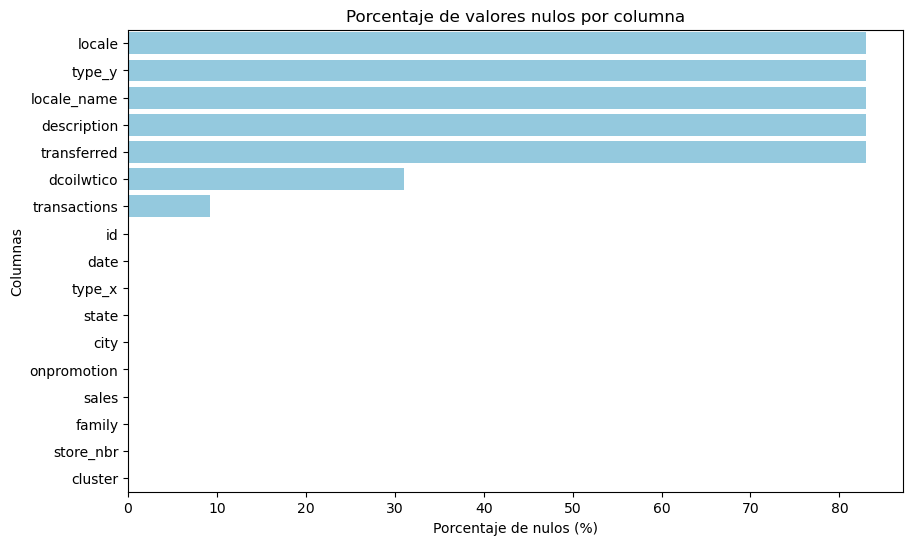

In [21]:
# Hacemos la grafica para ver mejor los nulos con su porcentaje 
porc_nulos = (df_train.isnull().sum() / len(df_train) * 100).to_frame()
porc_nulos.columns = ["porc_nulos"]

porc_nulos = porc_nulos.reset_index().rename(columns={'index': 'column'})

missing_df = porc_nulos.sort_values(by="porc_nulos", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=missing_df, x="porc_nulos", y="column", color="skyblue")

plt.title("Porcentaje de valores nulos por columna")
plt.xlabel("Porcentaje de nulos (%)")
plt.ylabel("Columnas")
plt.show()

ANÁLISIS UNIVARIANTE

Estadistica descriptiva

In [22]:
df_train.describe().T

,count,mean,min,25%,50%,75%,max,std
id,2642706.0,1302440.228928,0.0,651766.25,1301750.5,1955298.75,2596373.0,750272.745809
date,2642706,2015-01-02 21:50:51.382333,2013-01-01 00:00:00,2014-01-02 00:00:00,2015-01-03 00:00:00,2016-01-06 00:00:00,2016-12-31 00:00:00,NaN
store_nbr,2642706.0,27.5,1.0,14.0,27.5,41.0,54.0,15.585787
sales,2642706.0,339.994847,0.0,0.0,9.0,185.0,124717.0,1061.583133
onpromotion,2642706.0,1.963957,0.0,0.0,0.0,0.0,741.0,11.038151
cluster,2642706.0,8.481481,1.0,4.0,8.5,13.0,17.0,4.649735
transactions,2398935.0,1704.314726,5.0,1049.0,1399.0,2103.0,8359.0,972.020822
dcoilwtico,1822986.0,70.838446,26.19,46.28,60.01,97.1,110.62,26.420837


In [23]:
#Para ver la moda
df_train.mode().T

,0,1,2,3,4,5,6,7,8,9,...,1772,1773,1774,1775,1776,1777,1778,1779,1780,1781
id,960498,960499,960500,960501,960502,960503,960504,960505,960506,960507,...,962270,962271,962272,962273,962274,962275,962276,962277,962278,962279
date,2014-06-25 00:00:00,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,...,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
store_nbr,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
family,AUTOMOTIVE,BABY CARE,BEAUTY,BEVERAGES,BOOKS,BREAD/BAKERY,CELEBRATION,CLEANING,DAIRY,DELI,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sales,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
onpromotion,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,Quito,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,Pichincha,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type_x,D,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cluster,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
# Calcular moda (elimino 'id' y 'date' ya que no aportan información relevante)
df_train.drop(columns=["id", "date"]).mode().T

,0,1,2,3,4,5,6,7,8,9,...,44,45,46,47,48,49,50,51,52,53
store_nbr,1,2,3,4,5,6,7,8,9,10,...,45,46,47,48,49,50,51,52,53,54
family,AUTOMOTIVE,BABY CARE,BEAUTY,BEVERAGES,BOOKS,BREAD/BAKERY,CELEBRATION,CLEANING,DAIRY,DELI,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sales,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
onpromotion,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,Quito,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,Pichincha,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type_x,D,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cluster,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transactions,1207.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dcoilwtico,47.72,60.01,93.12,95.25,96.44,107.04,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
# Calcular IQR (rango intercuartilico)
df_train.describe().T["75%"] - df_train.describe().T["25%"]

id                      1303532.5
date            734 days 00:00:00
store_nbr                    27.0
sales                       185.0
onpromotion                   0.0
cluster                       9.0
transactions               1054.0
dcoilwtico                  50.82
dtype: object

In [26]:
# Calcular rango
df_train.describe().T["max"] - df_train.describe().T["min"]

id                       2596373.0
date            1460 days 00:00:00
store_nbr                     53.0
sales                     124717.0
onpromotion                  741.0
cluster                       16.0
transactions                8354.0
dcoilwtico                   84.43
dtype: object

Para sacar el skew hemos quitado la columna date, porque no es un numero int o float

In [27]:
# Calcular asimetría
"""
valor > 0 -> distribución asimétrica a la derecha
valor = 0 -> distribución simétrica
valor < 0 -> distribución asimétrica a la izquierda
"""
df_train[num_columns].skew()

id              -0.006142
store_nbr        0.000000
sales            7.968330
onpromotion     13.806275
cluster          0.040087
transactions     1.533886
dcoilwtico       0.053681
dtype: float64

In [28]:
# Calcular la curtosis
"""
valor > 0 -> distribución leptocúrtica
valor = 0 -> distribución mesocúrtica
valor < 0 -> distribución platicúrtica
"""
df_train[num_columns].kurt()

id               -1.204972
store_nbr        -1.200823
sales           206.962567
onpromotion     374.341183
cluster          -1.256245
transactions      2.708895
dcoilwtico       -1.717567
dtype: float64

# Visualizaciones

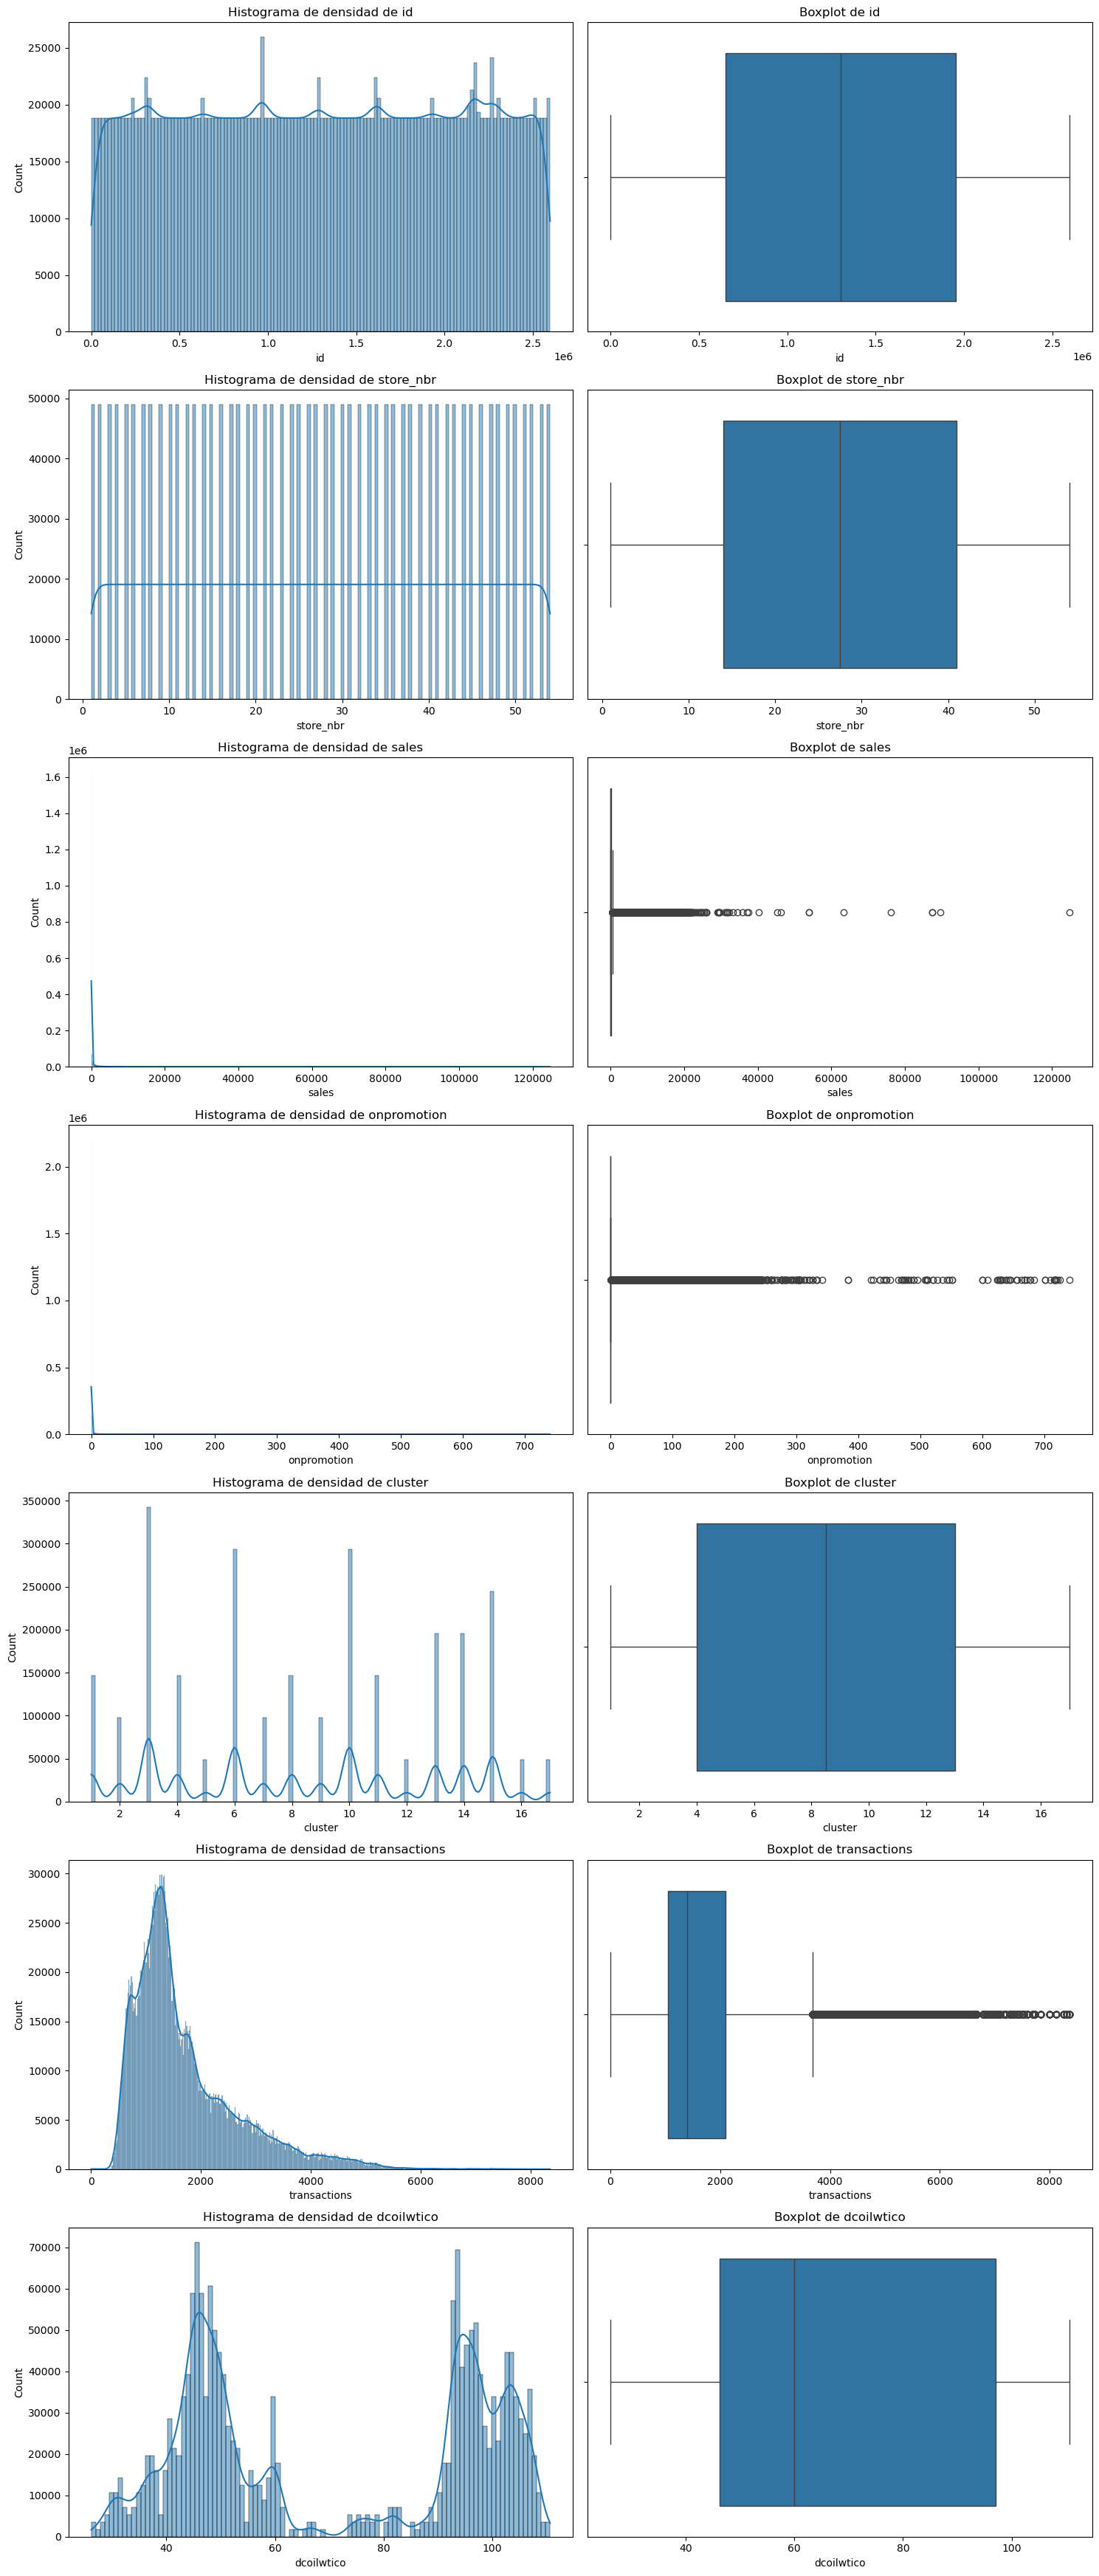

In [29]:
fig, axes = plt.subplots(nrows=len(num_columns), ncols=2, figsize=(15, 5 * len(num_columns)))

for i, column in enumerate(df_train[num_columns]):
    # Histograma de densidad
    sns.histplot(df_train[column], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'Histograma de densidad de {column}')
    
    # Boxplot
    sns.boxplot(x=df_train[column], ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot de {column}')

plt.tight_layout()
plt.show()

id: La grafica no nos explica nada, ya que es casi todo constante

store_nbr: La grafica no nos explica nada, ya que es entera constante

sales: habria que pintar otra vez la grafica con ventas de 200 para ver si hay puntos aislados

onpromotion: habria que pintar otra vez la grafica con ventas de 200 para ver si hay puntos aislados. 

cluster: 

transactions: 

dcoilwtico: si hay alguna variable que afectara al precio de la gasolina, ya que esta partido en dos

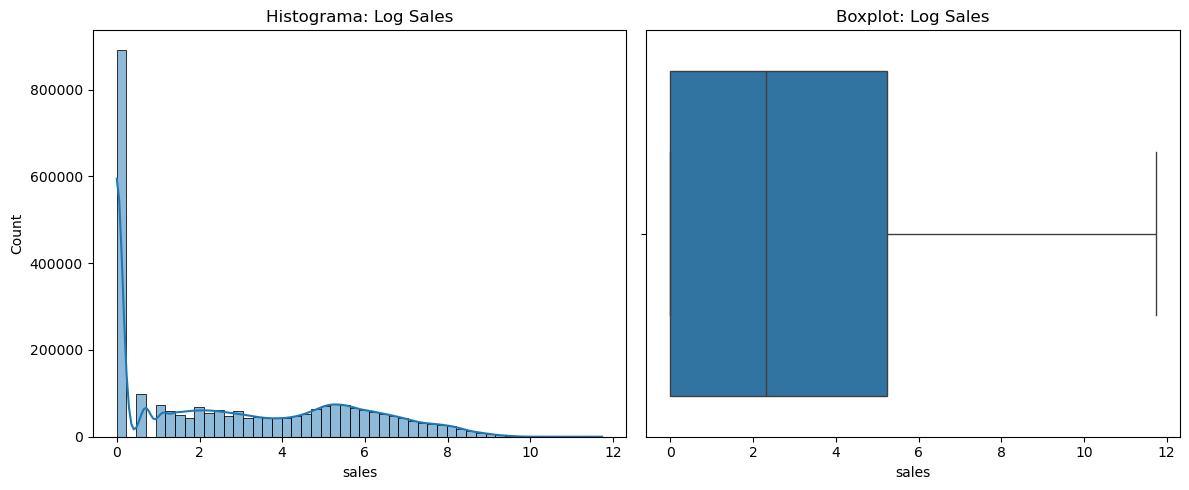

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#Histograma de densidad
sns.histplot(np.log1p(df_train["sales"]), bins=50, kde=True, ax=axes[0])
axes[0].set_title("Histograma: Log Sales")

# Boxplot
sns.boxplot(x=np.log1p(df_train["sales"]), ax=axes[1])
axes[1].set_title("Boxplot: Log Sales")

plt.tight_layout()
plt.show()

Lo ponemos en el preprocessing

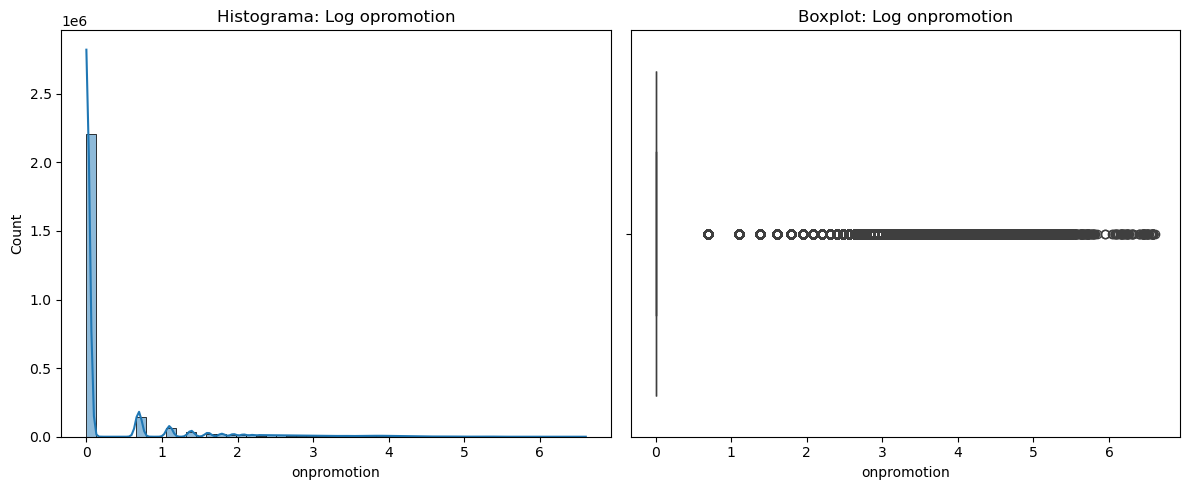

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#Histograma de densidad
sns.histplot(np.log1p(df_train["onpromotion"]), bins=50, kde=True, ax=axes[0])
axes[0].set_title("Histograma: Log opromotion")

# Boxplot
sns.boxplot(x=np.log1p(df_train["onpromotion"]), ax=axes[1])
axes[1].set_title("Boxplot: Log onpromotion")

plt.tight_layout()
plt.show()

No log

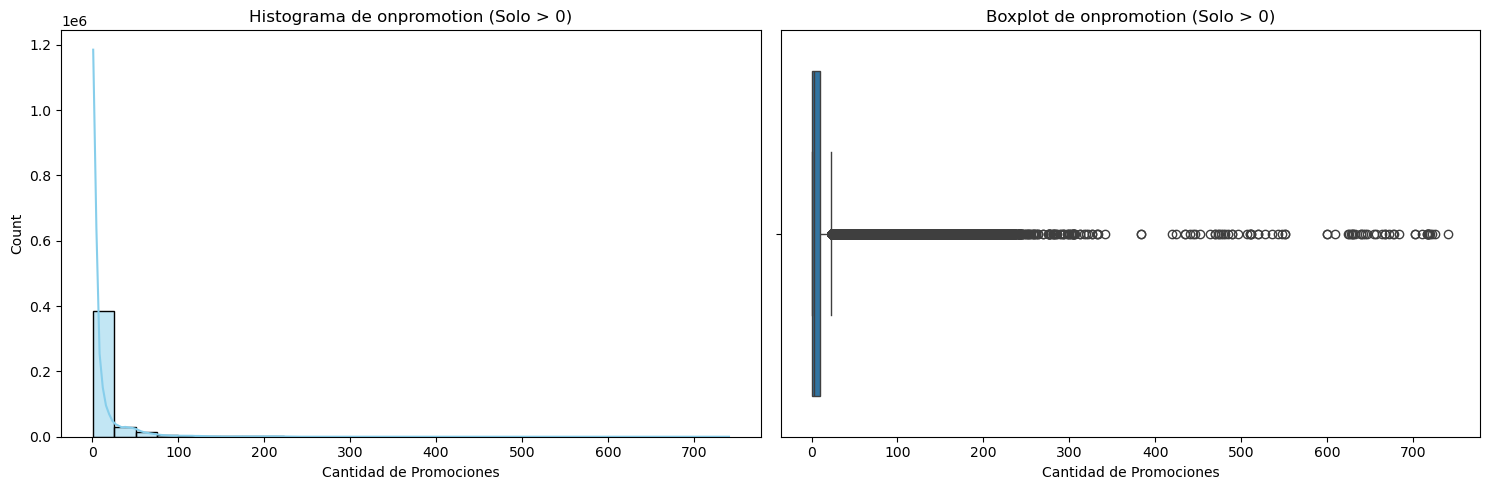

In [54]:
df_filtered = df_train[df_train['onpromotion'] > 0]

# 2. Creamos la figura con dos subplots (una fila, dos columnas)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograma (Densidad)
sns.histplot(df_filtered['onpromotion'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Histograma de onpromotion (Solo > 0)')
axes[0].set_xlabel('Cantidad de Promociones')

# Boxplot
sns.boxplot(x=df_filtered['onpromotion'], ax=axes[1])
axes[1].set_title('Boxplot de onpromotion (Solo > 0)')
axes[1].set_xlabel('Cantidad de Promociones')

plt.tight_layout()
plt.show()

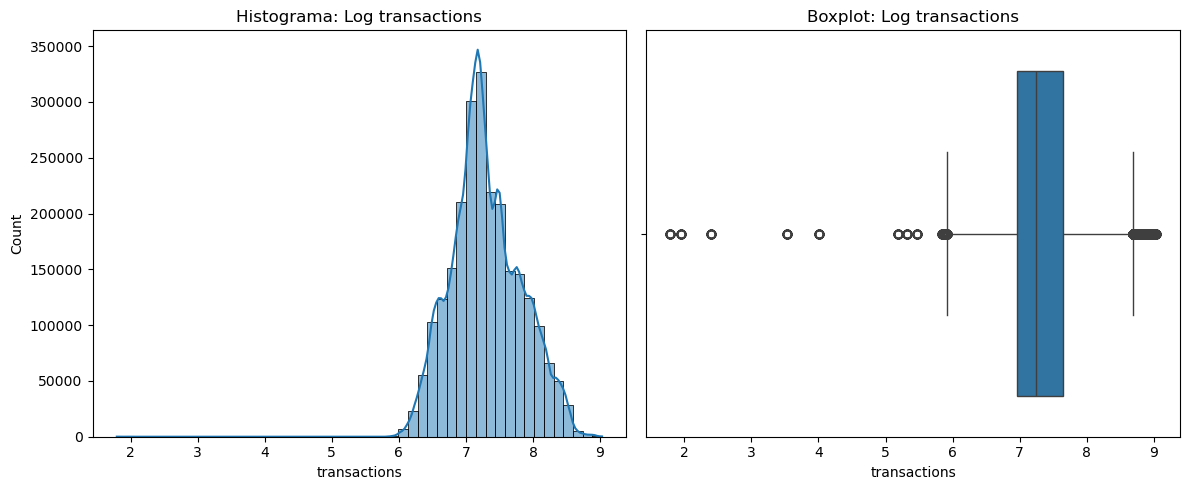

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#Histograma de densidad
sns.histplot(np.log1p(df_train["transactions"]), bins=50, kde=True, ax=axes[0])
axes[0].set_title("Histograma: Log transactions")

# Boxplot
sns.boxplot(x=np.log1p(df_train["transactions"]), ax=axes[1])
axes[1].set_title("Boxplot: Log transactions")

plt.tight_layout()
plt.show()

Si aplicamos log

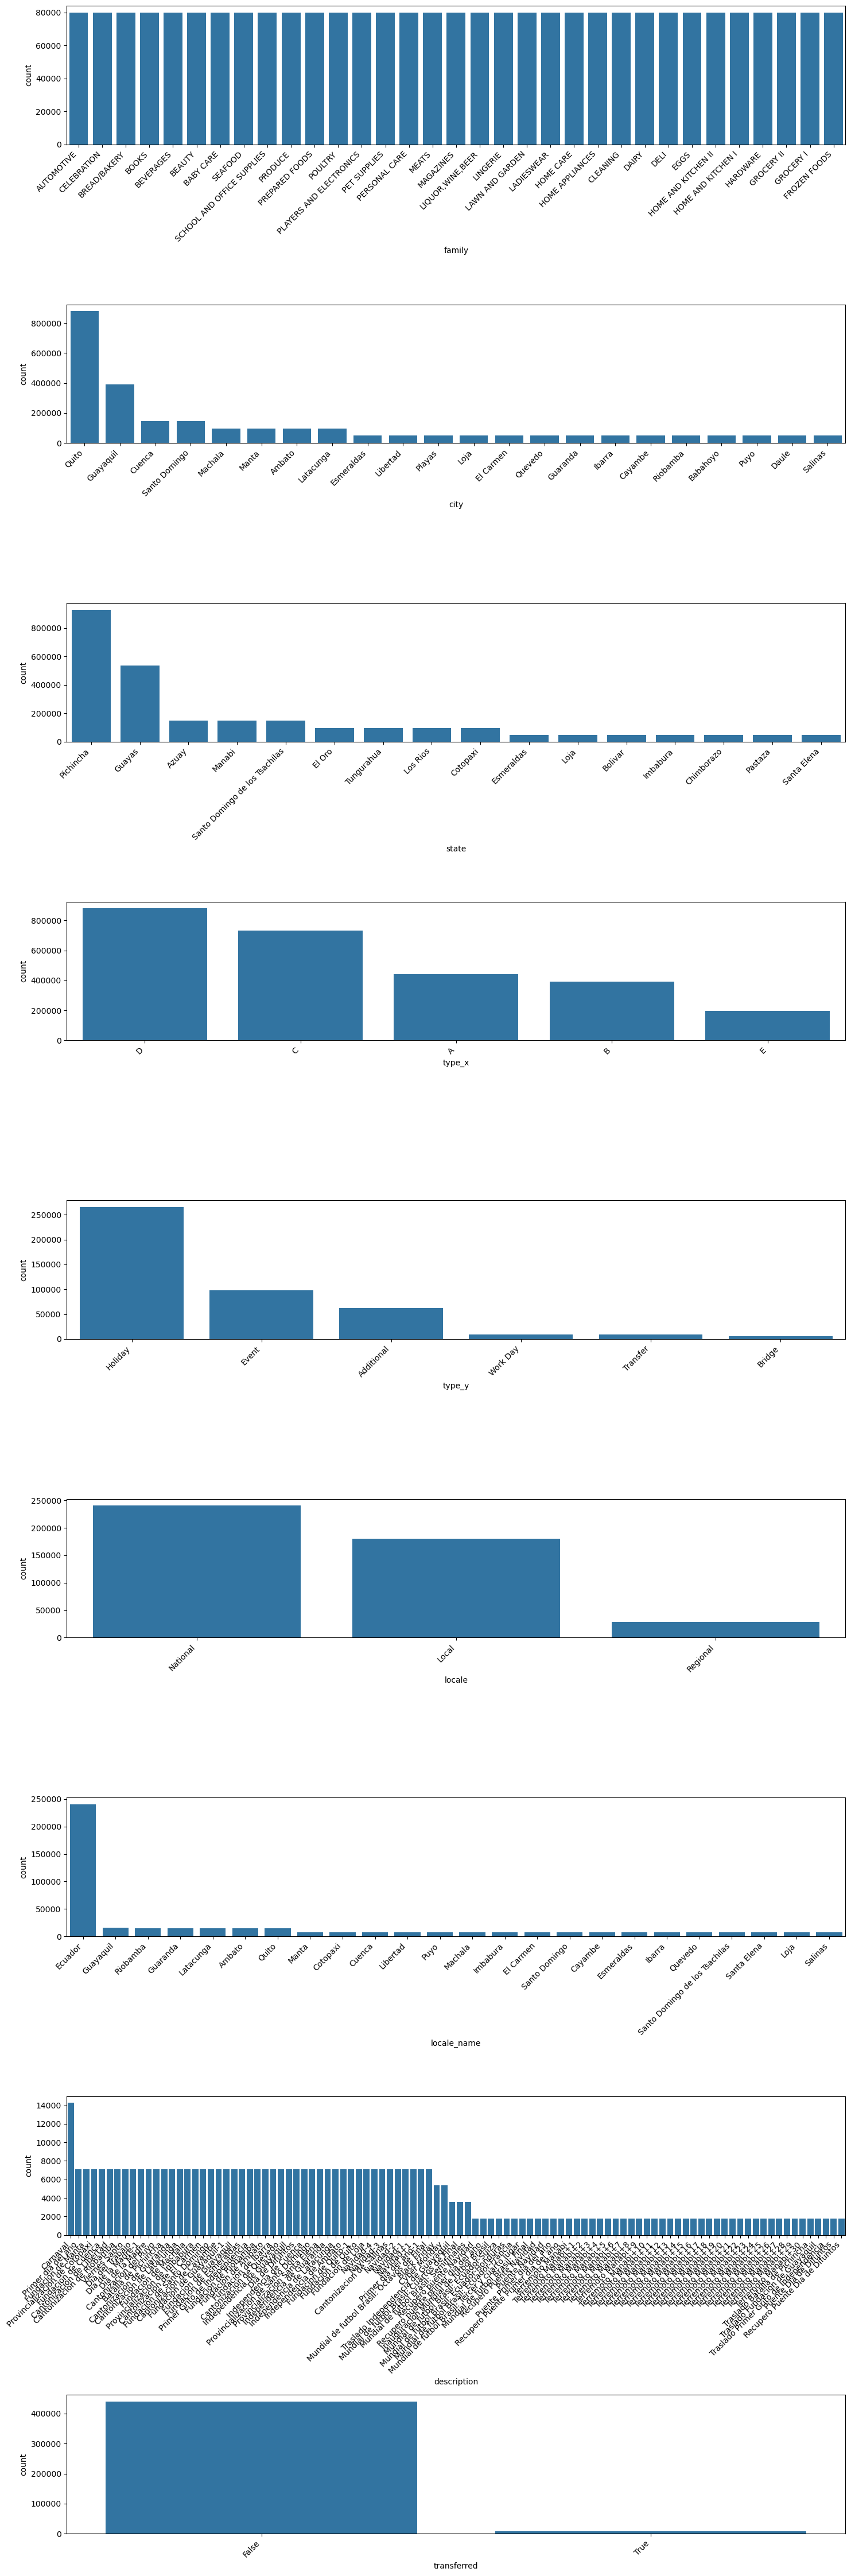

In [34]:
fig, axes = plt.subplots(nrows=len(cat_columns), ncols=1, figsize=(15, 5 * len(cat_columns)))

for i, col in enumerate(cat_columns):
    # Gráfico básico ordenado
    sns.countplot(data=df_train, x=col, ax=axes[i], order=df_train[col].value_counts().index)
    
    # Lo mínimo para que los nombres no se muevan: rotación y alineación derecha
    axes[i].tick_params(axis='x', rotation=45)
    for tick in axes[i].get_xticklabels():
        tick.set_horizontalalignment('right')

plt.tight_layout()
plt.show()

In [35]:
for col in cat_columns:
    print(col, df_train[col].nunique())

family 33
city 22
state 16
type_x 5
type_y 6
locale 3
locale_name 24
description 100
transferred 2


Tenemos poca cardinalidad, entonces no vamos a modificar nada

Analisis bivariado

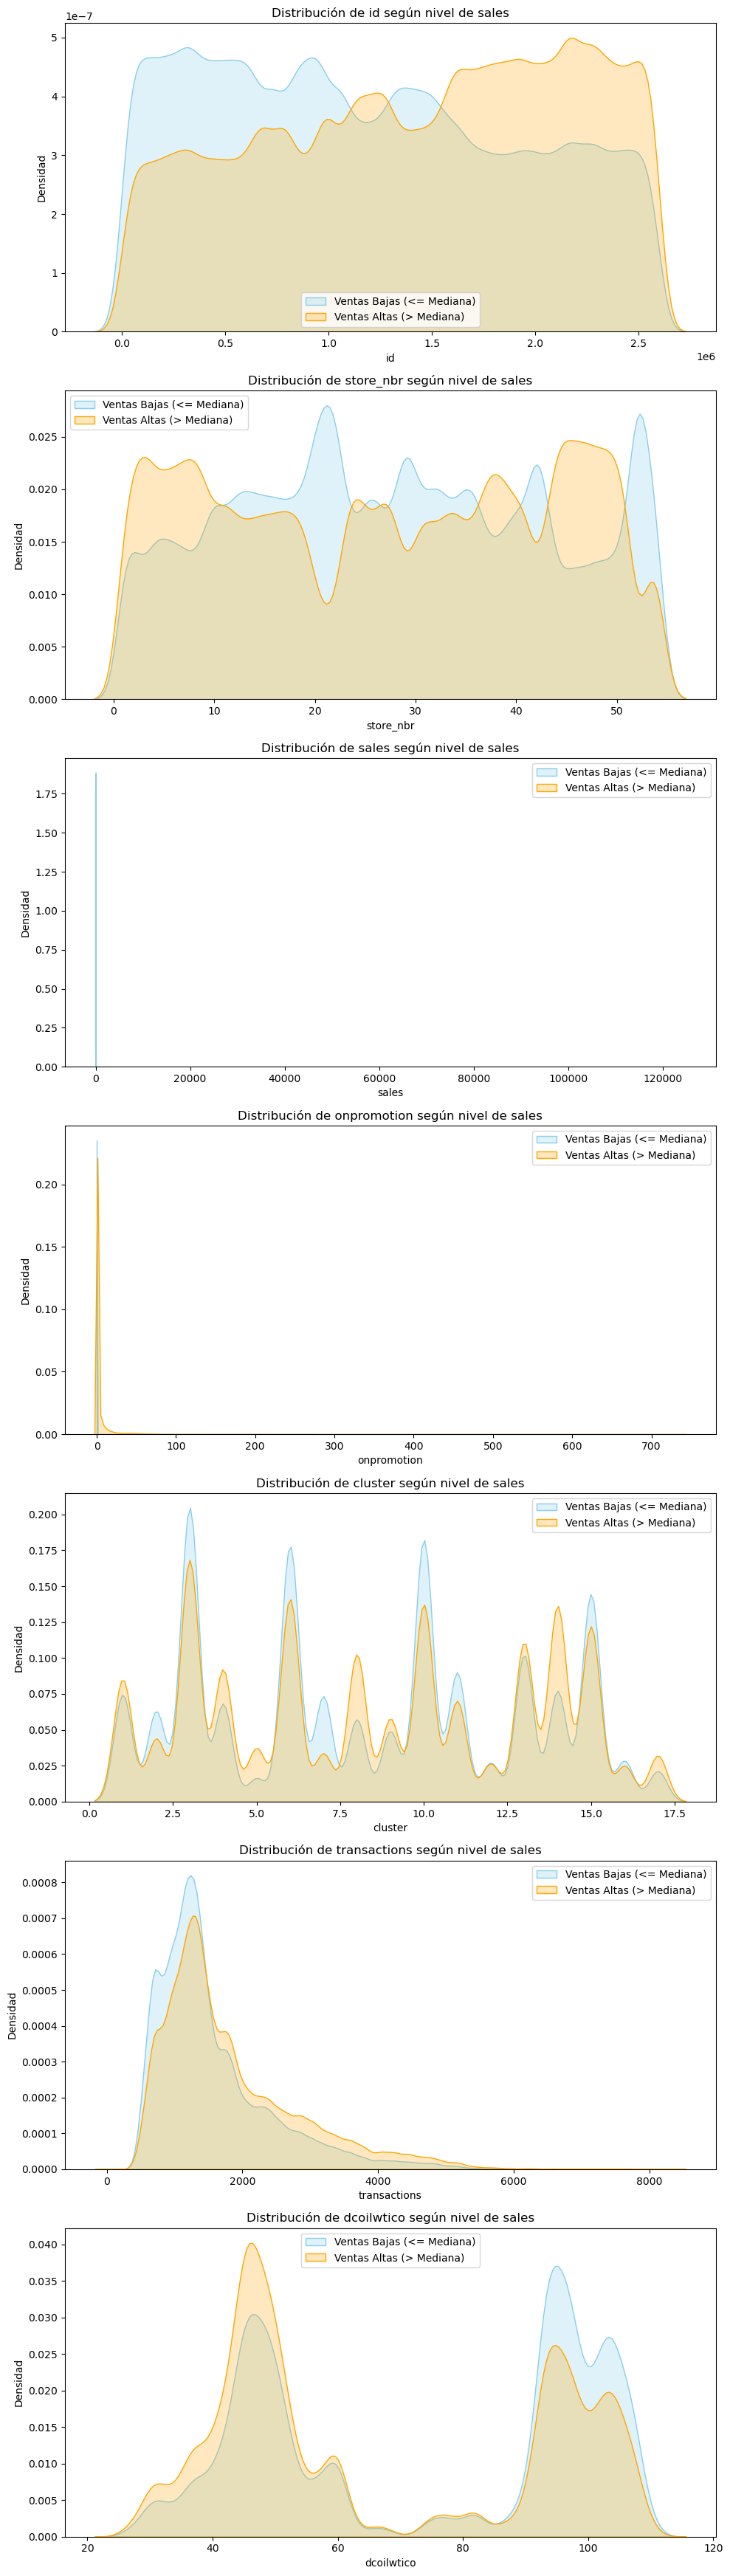

In [36]:
target="sales"

# Definir un umbral para comparar
threshold = df_train[target].median()

# Corregir plt.subplots
fig, axs = plt.subplots(nrows=len(num_columns), ncols=1, figsize=(10, 5 * len(num_columns)))

# Asegurarse de que axs sea una lista si solo hay una columna
if len(num_columns) == 1:
    axs = [axs]

# Graficar cada columna numérica
for i, col in enumerate(num_columns):
    # Grupo de ventas bajas
    sns.kdeplot(data=df_train[df_train[target] <= threshold], x=col, 
                ax=axs[i], label='Ventas Bajas (<= Mediana)', fill=True, color="skyblue")
    
    # Grupo de ventas altas
    sns.kdeplot(data=df_train[df_train[target] > threshold], x=col, 
                ax=axs[i], label='Ventas Altas (> Mediana)', fill=True, color="orange")
    
    axs[i].set_title(f'Distribución de {col} según nivel de {target}')
    axs[i].set_xlabel(col)
    axs[i].set_ylabel('Densidad')
    axs[i].legend()

plt.tight_layout()
plt.show()

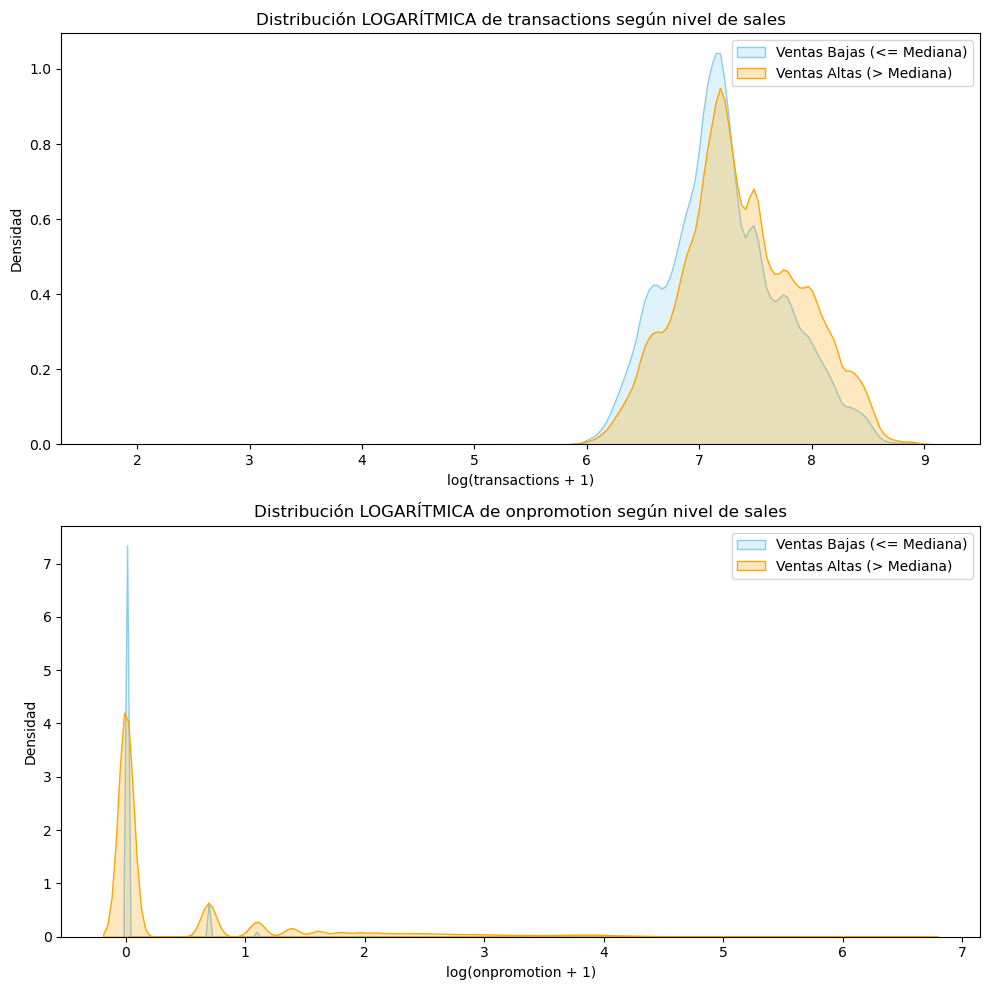

In [37]:
# Seleccionamos solo las columnas que queremos testear con logaritmo
cols_to_test = ["transactions", "onpromotion"]
target = "sales"
threshold = df_train[target].median()

fig, axs = plt.subplots(nrows=len(cols_to_test), ncols=1, figsize=(10, 5 * len(cols_to_test)))

for i, col in enumerate(cols_to_test):
    # Aplicamos logaritmo en el eje X: np.log1p(df[col])
    # Grupo de ventas bajas
    sns.kdeplot(x=np.log1p(df_train[df_train[target] <= threshold][col]), 
                ax=axs[i], label='Ventas Bajas (<= Mediana)', fill=True, color="skyblue")
    
    # Grupo de ventas altas
    sns.kdeplot(x=np.log1p(df_train[df_train[target] > threshold][col]), 
                ax=axs[i], label='Ventas Altas (> Mediana)', fill=True, color="orange")
    
    axs[i].set_title(f'Distribución LOGARÍTMICA de {col} según nivel de {target}')
    axs[i].set_xlabel(f'log({col} + 1)')
    axs[i].set_ylabel('Densidad')
    axs[i].legend()

plt.tight_layout()
plt.show()

Analisis Multivariante

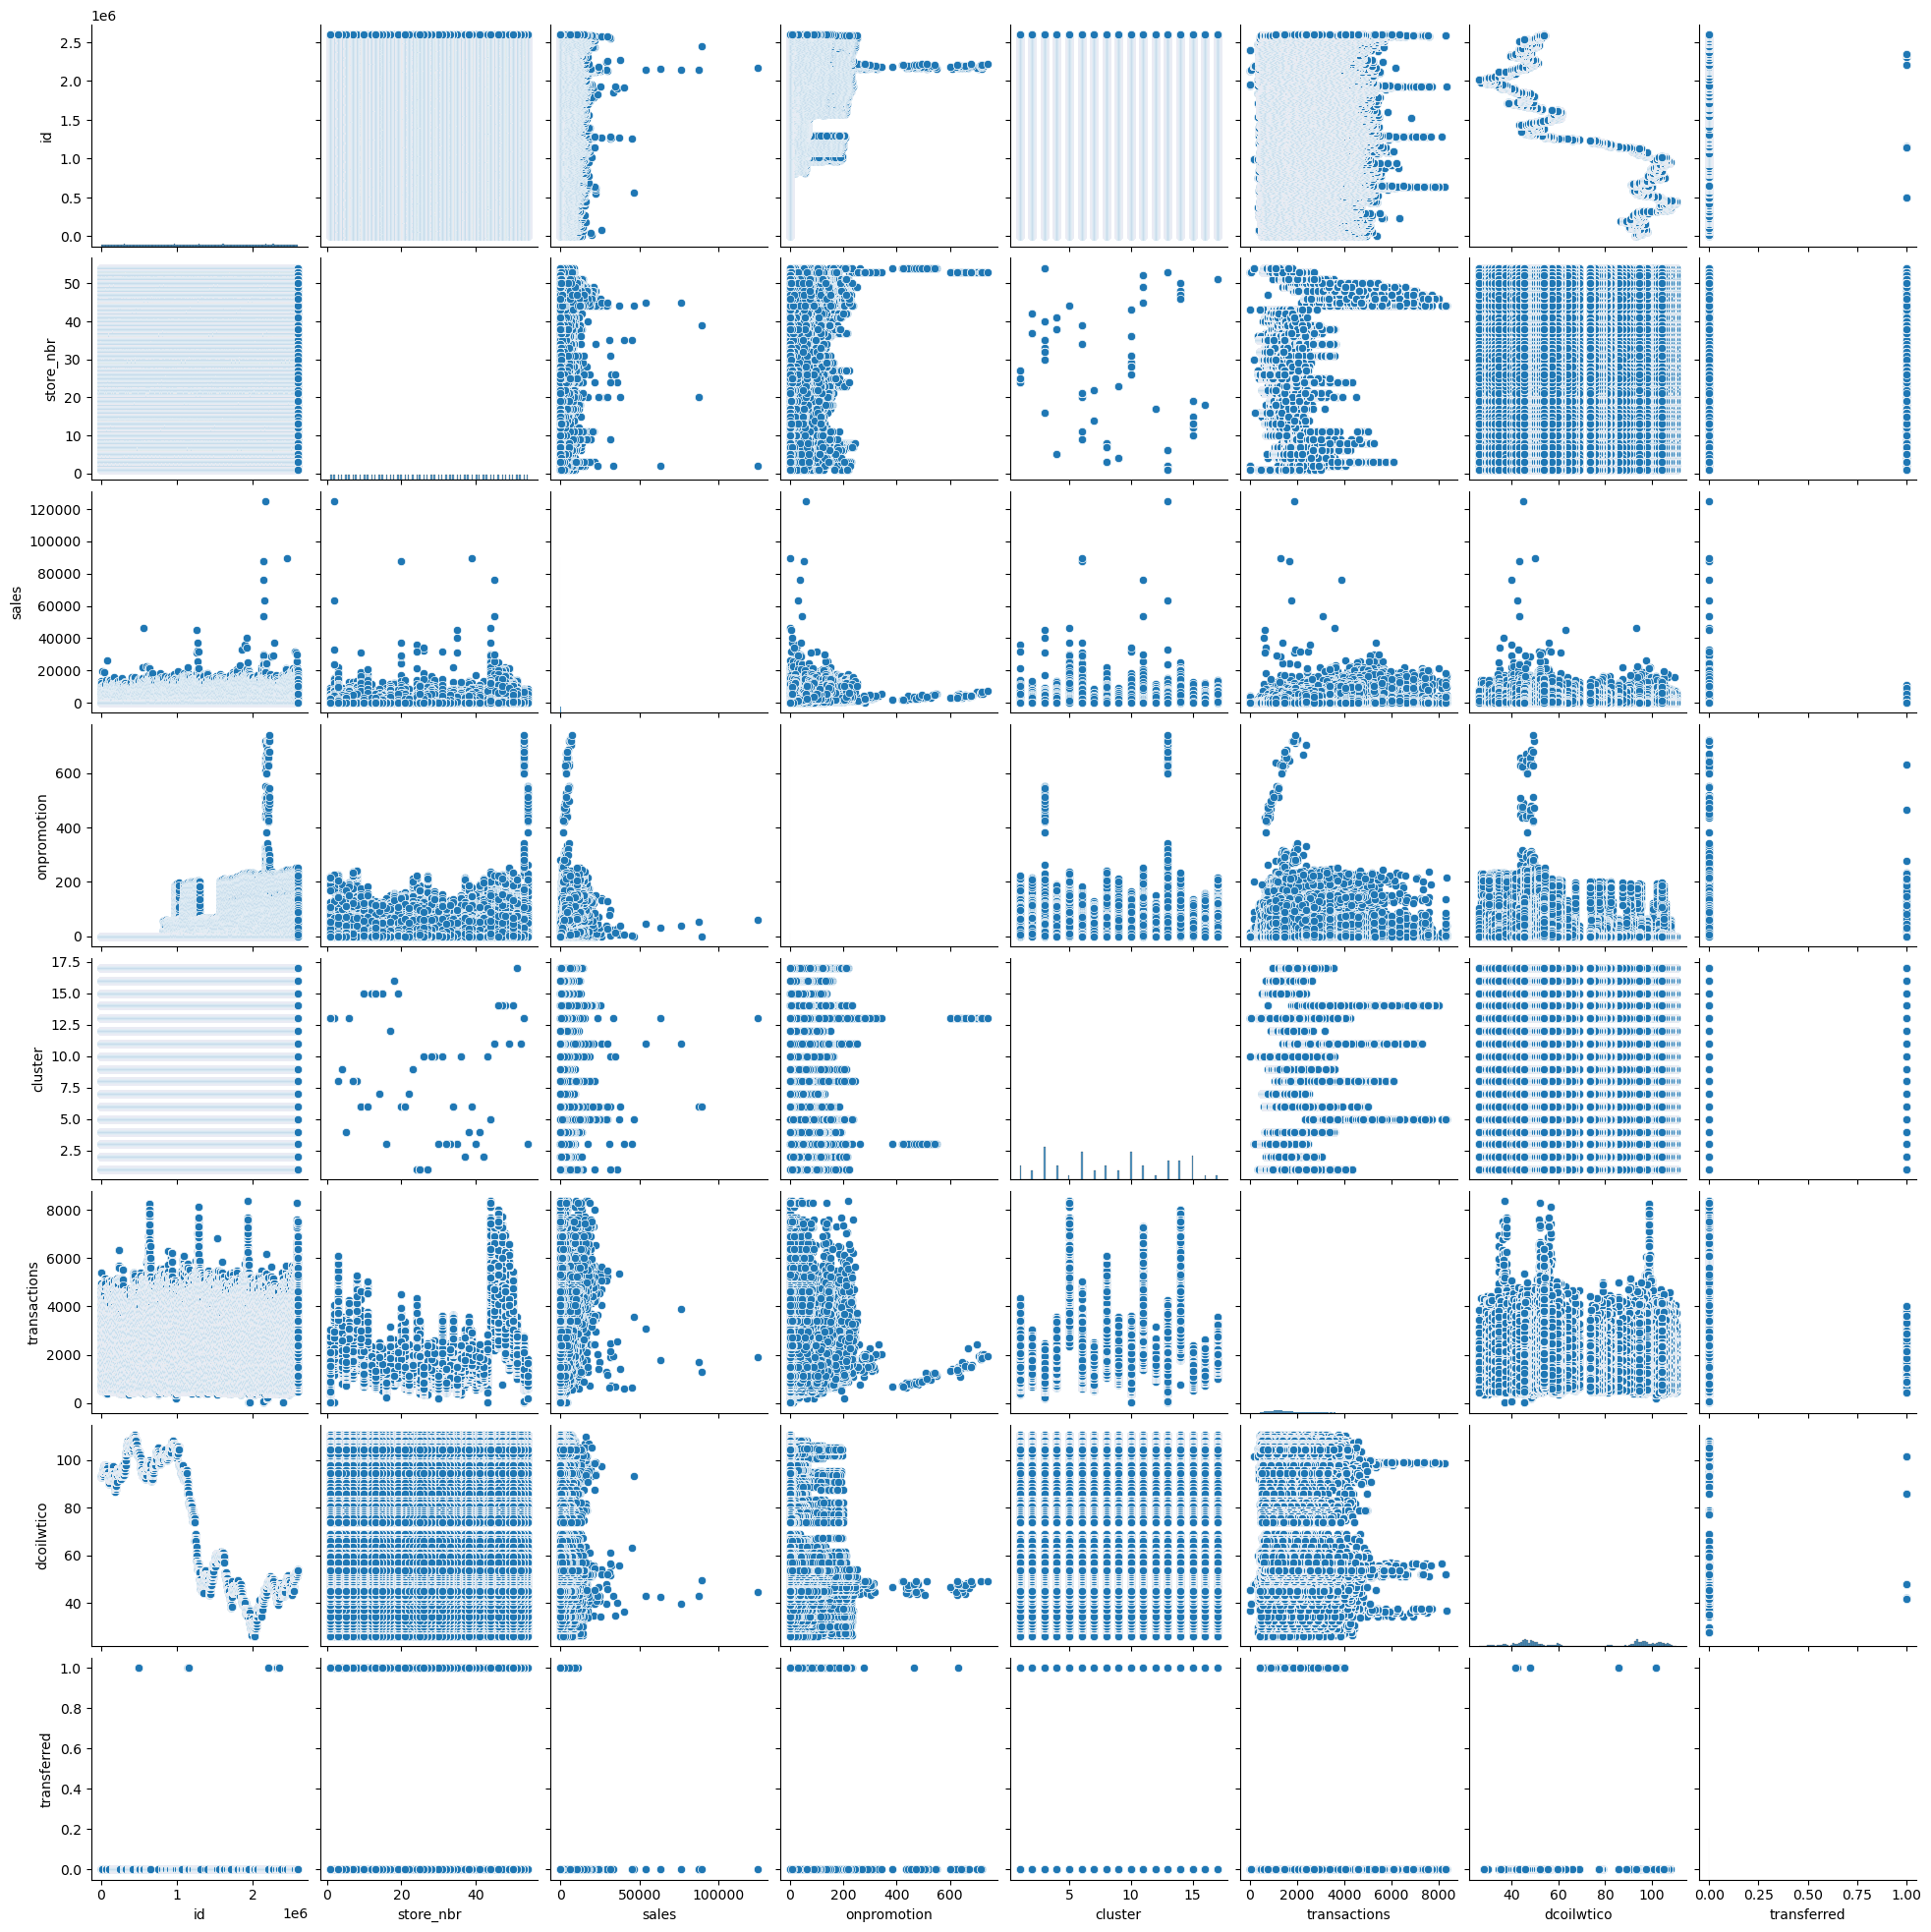

In [38]:
sns.pairplot(df_train);

In [39]:
# Correlaciones
df_train[num_columns].corr()

,id,store_nbr,sales,onpromotion,cluster,transactions,dcoilwtico
id,1.000000,3.479234e-04,0.084031,0.186341,-5.045050e-05,-0.023251,-8.675401e-01
store_nbr,0.000348,1.000000e+00,0.037928,0.008791,-5.928399e-02,0.184342,5.696358e-14
sales,0.084031,3.792796e-02,1.000000,0.380458,3.887294e-02,0.214337,-7.777738e-02
onpromotion,0.186341,8.791225e-03,0.380458,1.000000,5.168642e-03,0.025849,-1.437741e-01
cluster,-0.000050,-5.928399e-02,0.038873,0.005169,1.000000e+00,0.194521,4.054373e-14
transactions,-0.023251,1.843422e-01,0.214337,0.025849,1.945208e-01,1.000000,1.450783e-02
dcoilwtico,-0.867540,5.696358e-14,-0.077777,-0.143774,4.054373e-14,0.014508,1.000000e+00


In [40]:
#es importante eliminar nulos para el cálculo
df_oil = df_train.dropna(subset=['dcoilwtico'])

pearson = df_oil['sales'].corr(df_oil['dcoilwtico'], method='pearson')
print(f"Pearson: {pearson}")

Pearson: -0.07777737786770889


In [41]:
spearman = df_oil['sales'].corr(df_oil['dcoilwtico'], method='spearman')
print(f"Spearman: {spearman}")

Spearman: -0.17804189893276084


Observamos que la correlacion de pearson es practicamente 0, entonces no hay relacion lineal

La de Spearman es mas alta, pero sigue siendo muy debil

En conclusion las ventas y el precio del petroleo no tienen relacion lineal

In [42]:
# Defino un cmap para ver más claramente los colores
cmap = sns.diverging_palette(500, 10, as_cmap=True)

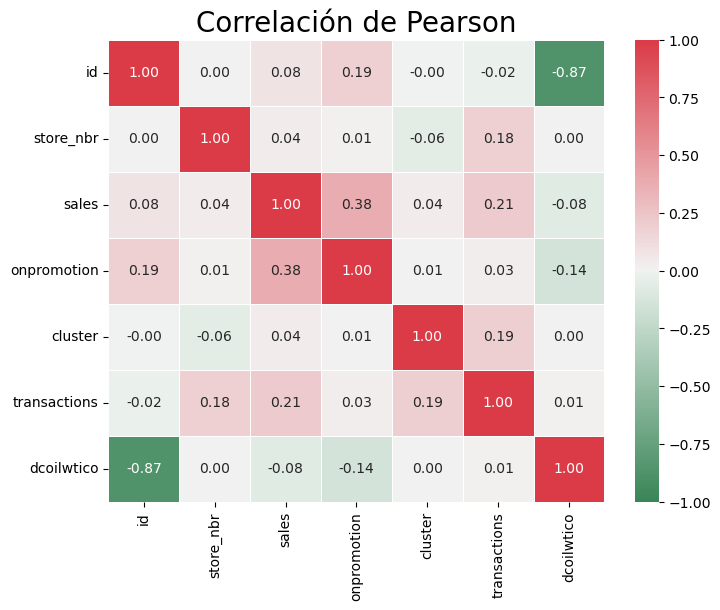

In [43]:
plt.figure(figsize=(8,6), dpi = 100)
sns.heatmap(df_train[num_columns].corr(method='pearson'),
            annot=True, 
            fmt=".2f", linewidth=.5, cmap=cmap, vmin=-1)
plt.title("Correlación de Pearson", fontsize =20)
plt.show()

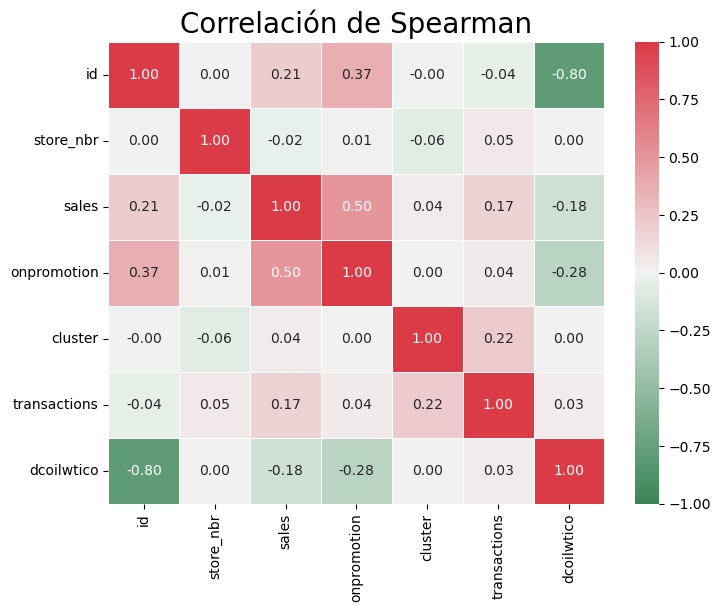

In [44]:
plt.figure(figsize=(8,6), dpi =100)
sns.heatmap(df_train[num_columns].corr(method='spearman'),
            annot=True, 
            fmt=".2f", linewidth=.5, cmap=cmap, vmin=-1)
plt.title("Correlación de Spearman", fontsize =20)
plt.show()

Vemos que no hay correlaciones bastante fuertes, excepto la de sales y onpromotion, las promociones impulsan las ventas.

# Hipotesis

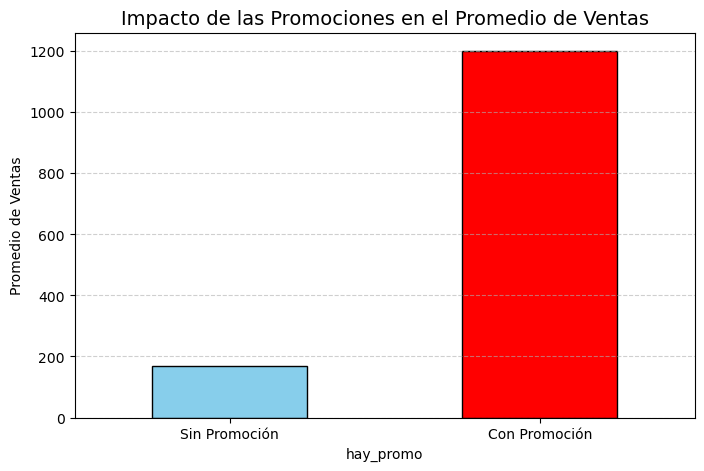

In [45]:
# 1 si hay promociones, 0 si no hay
df_train['hay_promo'] = (df_train['onpromotion'] > 0).astype(int)

# promedio de ventas para los dos
promo_impact = df_train.groupby('hay_promo')['sales'].mean()

plt.figure(figsize=(8, 5))
promo_impact.plot(kind='bar', color=['skyblue', 'red'], edgecolor='black')
plt.title('Impacto de las Promociones en el Promedio de Ventas', fontsize=14)
plt.xticks([0, 1], ['Sin Promoción', 'Con Promoción'], rotation=0)
plt.ylabel('Promedio de Ventas')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

Se ve muy claramente que los productos con promociones tienen una mayor venta, asi que validamos la hipotesis, aceptamos H1

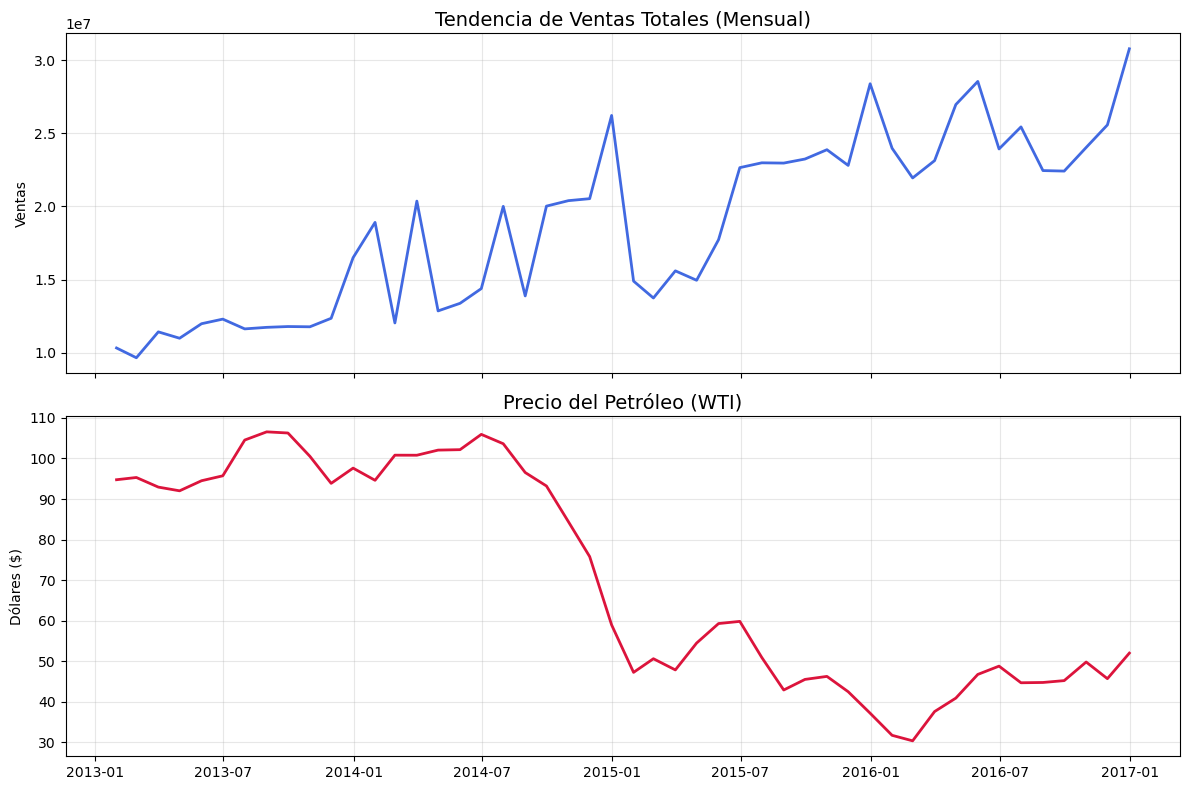

In [46]:
# 1. Preparar los datos (promedio mensual para que sea una línea clara)
data_plot = df_train.set_index('date').resample('ME').agg({'sales': 'sum', 'dcoilwtico': 'mean'})

# 2. Crear dos subgráficos (uno arriba del otro)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Gráfico de arriba: VENTAS
ax1.plot(data_plot.index, data_plot['sales'], color='royalblue', linewidth=2)
ax1.set_title('Tendencia de Ventas Totales (Mensual)', fontsize=14)
ax1.set_ylabel('Ventas')
ax1.grid(True, alpha=0.3)

# Gráfico de abajo: PETRÓLEO
ax2.plot(data_plot.index, data_plot['dcoilwtico'], color='crimson', linewidth=2)
ax2.set_title('Precio del Petróleo (WTI)', fontsize=14)
ax2.set_ylabel('Dólares ($)')
ax2.grid(True, alpha=0.3)

# 3. Ajustar y mostrar
plt.tight_layout()
plt.show()

La hipotesis se rechaza porque no tiene correlacion alguna, ya que su correlacion es -0,08

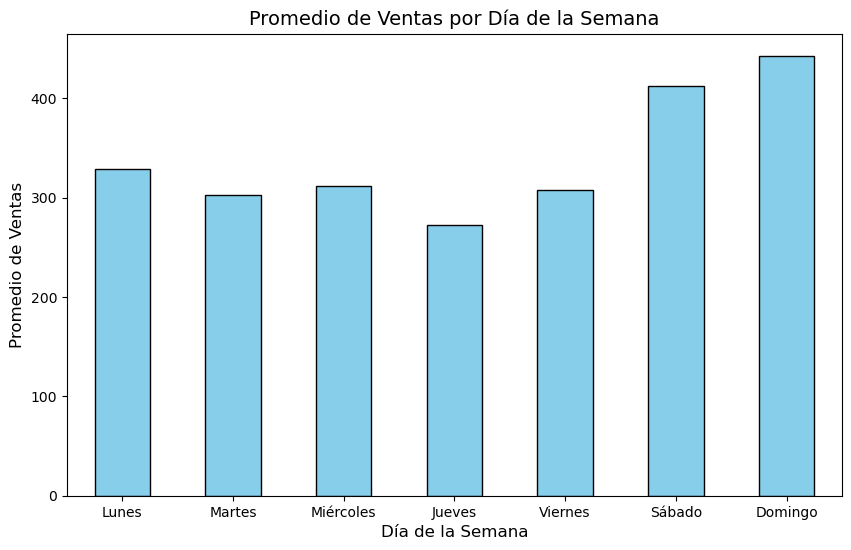

In [47]:
# Crear columna del día de la semana (0=Lunes, 6=Domingo)
df_train["dayofweek"] = df_train["date"].dt.dayofweek

# Calcular promedio de ventas por día
sales_by_day = df_train.groupby("dayofweek")["sales"].mean()

# Definir los nombres de los días
dias_nombres = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]

plt.figure(figsize=(10, 6))
sales_by_day.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Promedio de Ventas por Día de la Semana", fontsize=14)
plt.xlabel("Día de la Semana", fontsize=12)
plt.ylabel("Promedio de Ventas", fontsize=12)

# Poner los nombres rectos (rotation=0) y centrados
plt.xticks(range(7), dias_nombres, rotation=0)
plt.show()

Se nota que los fines de semana hay un incremento de ventas, Se acepta la hipotesis

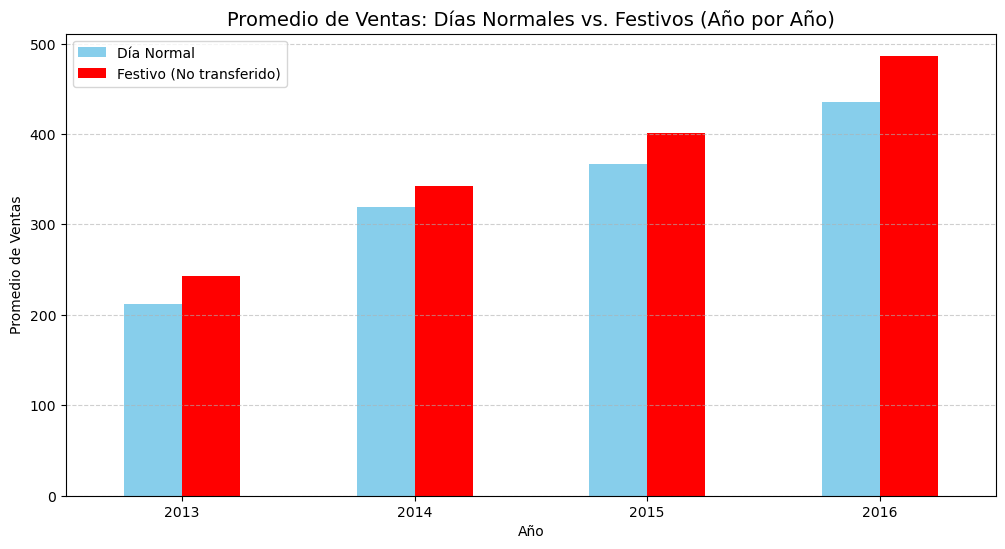

In [48]:
# Preparar feriados (sin transferidos y sin duplicados por fecha)
festivos_reales = holidays[holidays['transferred'] == False].drop_duplicates(subset=['date'])
fechas_festivas = set(festivos_reales['date'])

# Crear columnas
df_train['es_festivo'] = df_train['date'].isin(fechas_festivas).astype(int)
df_train['year'] = df_train['date'].dt.year

# promedio de ventas por Año y por tipo de Día
ventas_anuales_festivos = df_train.groupby(['year', 'es_festivo'])['sales'].mean().unstack()

plt.figure(figsize=(12, 6))
ventas_anuales_festivos.plot(kind='bar', ax=plt.gca(), color=["skyblue", 'red'])
plt.title("Promedio de Ventas: Días Normales vs. Festivos (Año por Año)", fontsize=14)
plt.xlabel("Año")
plt.ylabel("Promedio de Ventas")
plt.legend(['Día Normal', 'Festivo (No transferido)'], loc='upper left')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

Tambien se acepta la hipotesis, porque vemos que las ventas han aumentado segun pasan los años, y que hay mas ventas los dias que hay festivos

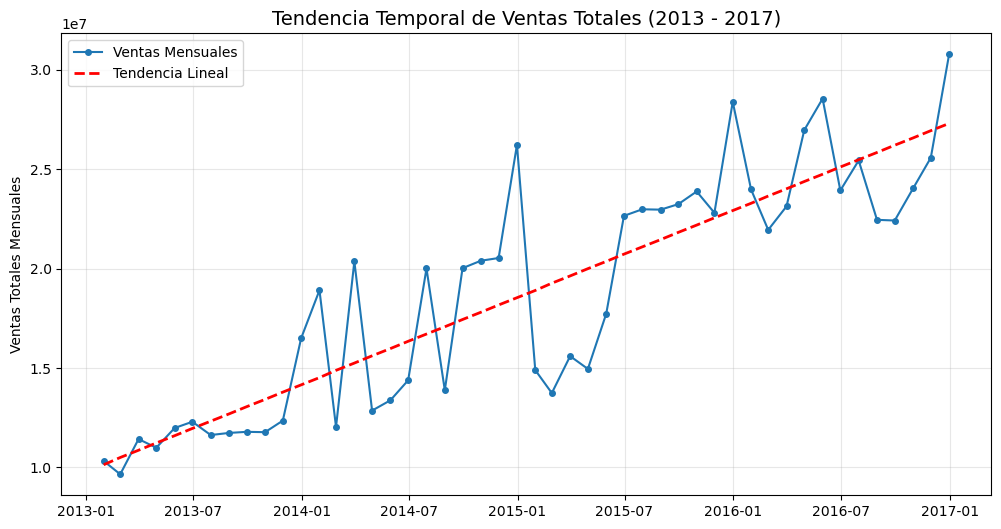

In [49]:
import numpy as np

# 1. Agrupar ventas por mes
trend_data = df_train.set_index('date').resample('ME')['sales'].sum()

# 2. Crear la gráfica base
plt.figure(figsize=(12, 6))
plt.plot(trend_data.index, trend_data.values, label='Ventas Mensuales', marker='o', markersize=4)

# 3. Calcular la línea de tendencia usando un índice numérico (0 a N)
x_numeric = np.arange(len(trend_data)) 
y_values = trend_data.values

z = np.polyfit(x_numeric, y_values, 1)
p = np.poly1d(z)

# 4. Dibujar la línea roja sobre las fechas originales
plt.plot(trend_data.index, p(x_numeric), "r--", linewidth=2, label="Tendencia Lineal")

# 5. Configuración final
plt.title('Tendencia Temporal de Ventas Totales (2013 - 2017)', fontsize=14)
plt.ylabel('Ventas Totales Mensuales')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Aceptamos la hipotesis, porque en la evolucion temporal vemos que hay picos en fechas especificas, pero las ventas estan aumentando con los años. Es para ver si hay añgun patron de estacionalidad 

Hemos investigado el terremoto con los datos principales (sin la particion), porque queriamos validar la hipotesis para ver si teniamos que cambiar ña particion del train y del test. Y ha salido que si lo tenemos que cambiar

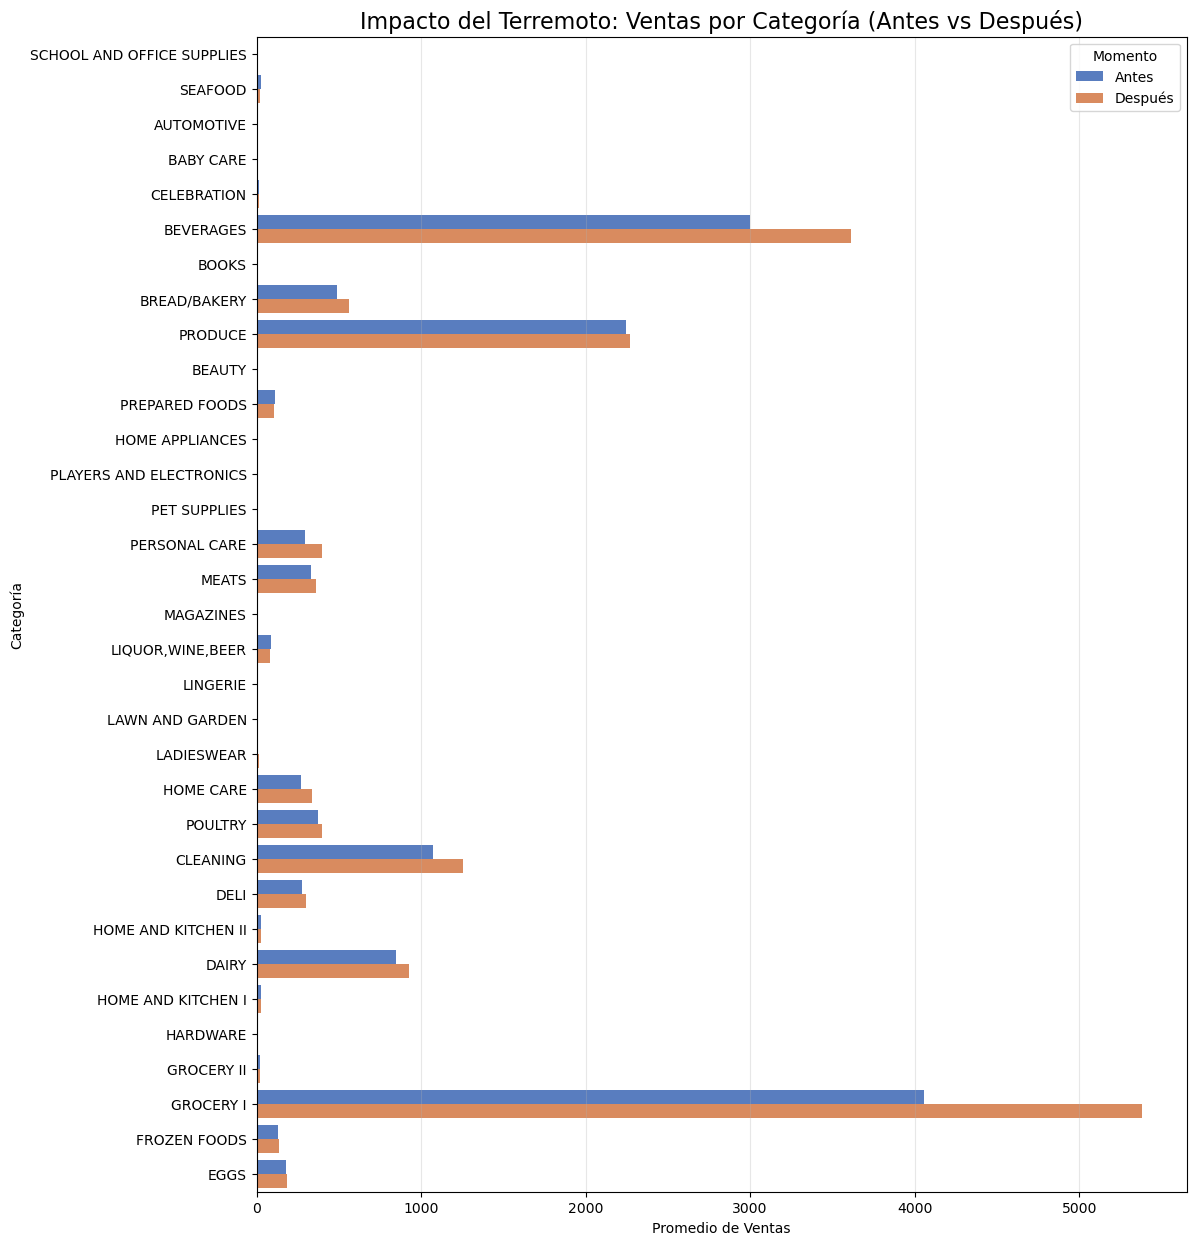

In [50]:
# 1. Preparar fechas
fecha_hitos = pd.to_datetime('2016-04-16')
df_train['date'] = pd.to_datetime(df_train['date'])

# 2. Crear etiquetas 'Antes' y 'Después'
df_train['Momento'] = df_train['date'].apply(lambda x: 'Antes' if x < fecha_hitos else 'Después')

# 3. Filtrar ventana de tiempo (1 mes antes y 1 mes después)
mask = (df_train['date'] >= '2016-03-16') & (df_train['date'] <= '2016-05-16')
total = df_train.loc[mask]

# 4. Graficar (Horizontal para que quepan todas las categorías)
plt.figure(figsize=(12, 15)) # Más alto para que entren todas las filas
sns.barplot(
    data=total, 
    y='family',     # Categorías en el eje Y
    x='sales',      # Ventas en el eje X
    hue='Momento',  # Comparación Antes/Después
    palette='muted',
    errorbar=None   # Elimina las líneas de error para que sea más limpio
)

plt.title('Impacto del Terremoto: Ventas por Categoría (Antes vs Después)', fontsize=16)
plt.xlabel('Promedio de Ventas')
plt.ylabel('Categoría')
plt.grid(axis='x', alpha=0.3)
plt.show()

Podemos ver que cunado ocurrio el terremos las ventas de algunos productos aumentaron drasticamente. Es decir, aceptamos la hipotesis

# Conclusiones: 
1. Las variables del Id y el store_nbr, son identificadores y no aportan información.
2. Las variables sales, transactions y onpromotion, tienen mucho sesgo a la derecha. La mayoria de los registros tienen valores bajos, por eso en el histograma aparecen una curtosis muy alta a al izquierda y unas colas muy largas hacia la derecha. La solucion que habiamos pensado seria aplicar una transformacion logaritmica a las variables de sales y transaction porque asi normalizamos su distribución. Mientras que la variable onpromotion no le hariamos ningun cambio porque no vemos una mejora clara y no la eliminariamos porque tiene una correlacion alta con nuestra target.
3. La variable del precio del petroleo tiene una distribucion bimodal, es decir, tiene dos picos. Lo que nos indica que durante esos años hubo periodos con precios bajos y otros con precios altos. Siguiendo la matriz de correlación, no nos indica que el precio del petroleo afecte a las ventas. Los valores nulos del precio del petroleo parecen ser por dias sin cotización, por lo que lo rellenariamos por el ultimo registro que tenemos de esa variable. 
4. Las ciudades como Quito y Guayaquil son los que mas registros tienen en el dataset. Para evitar un modelo sobreajustado y disminuir la dimensionalidad del one hot encoding vamos a agrupar categorias que tengan pocos registros en una misma etiqueta.
5. Las columnas relacionado con feriado (type_y, local...) tienen un porcentaje de nulos superior al 70%, en vez de eliminar la columna hemos decidido transformarlas en una variable binaria (is_holidays), para ver si un dia en especifico es especial o no.